# Zomato Bengaluru - Exploratory Data Analysis
## Part 1 : Distributions
**Notebook:** `01_eda.ipynb`  
**Data:** `data/processed/zomato_clean.csv`  
**Palette:** `Set2` throughout for consistency


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

PALETTE = 'Set2'
FIG_DIR = pathlib.Path('../outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette=PALETTE, font_scale=1.15)
matplotlib.rcParams['figure.dpi'] = 120

def save_fig(name):
    path = FIG_DIR / name
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved -> {path}')

df = pd.read_csv('../data/processed/zomato_clean.csv')
df['rating_bucket'] = pd.Categorical(df['rating_bucket'], categories=['Poor','Average','Good','Excellent'], ordered=True)
print(f'Loaded {len(df):,} rows x {df.shape[1]} cols')
df.head(3)

Loaded 5,500 rows x 17 cols


,name,online_order,book_table,rate,votes,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type),listed_in(city),cuisine_count,is_chain,price_per_person,has_online_order,rating_bucket
0,Urban Corner,No,Yes,3.8,5220,Jp Nagar,Sweet Shop,Not Available,"Burger, Continental, Beverages",3500,Delivery,Jp Nagar,3,1,1750.0,False,Good
1,Golden Express,Yes,No,3.7,4566,Brookefield,Sweet Shop,Biryani,"Desserts, Continental",500,Cafes,Brookefield,2,1,250.0,True,Good
2,Green Bites,No,No,3.0,834,Yelahanka,Quick Bites,"Butter Chicken, Fried Rice, Biryani",Thai,300,Delivery,Yelahanka,1,1,150.0,False,Average


---
## Plot 1 - Rating Distribution Histogram
How are restaurant ratings spread across Bengaluru?


Saved -> ..\outputs\figures\01_rating_distribution.png


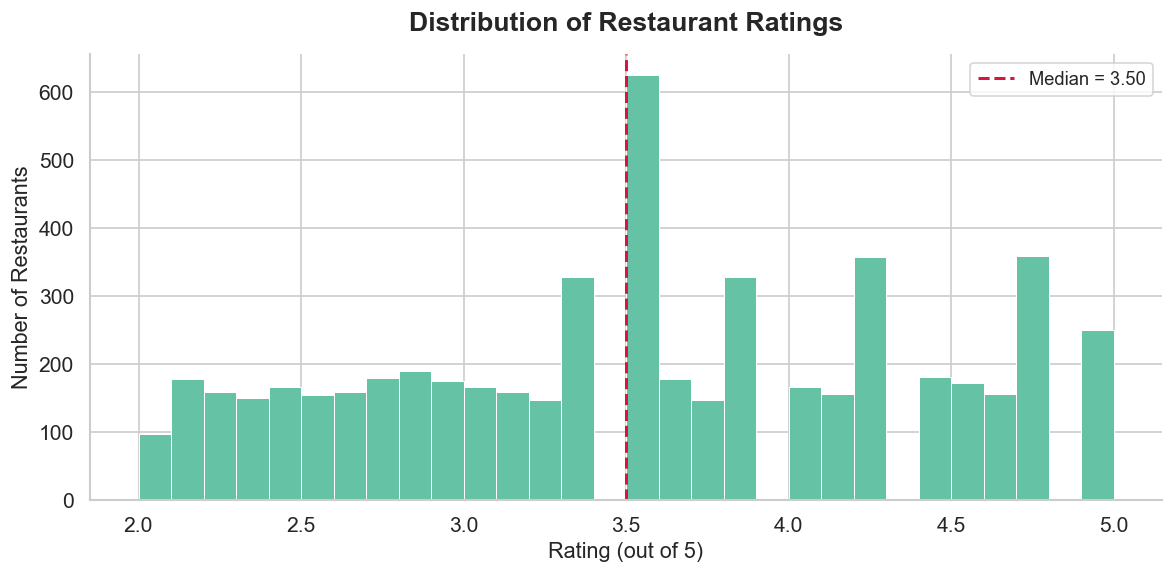

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['rate'].dropna(), bins=30, color=sns.color_palette(PALETTE)[0], edgecolor='white', linewidth=0.6)
median_val = df['rate'].median()
ax.axvline(median_val, color='crimson', linestyle='--', linewidth=1.8, label=f'Median = {median_val:.2f}')
ax.set_title('Distribution of Restaurant Ratings', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Rating (out of 5)', fontsize=13)
ax.set_ylabel('Number of Restaurants', fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
save_fig('01_rating_distribution.png')
plt.show()

---
## Plot 2 - Top 15 Locations by Restaurant Count
Which neighbourhoods have the highest density of restaurants?


Saved -> ..\outputs\figures\02_top15_locations.png


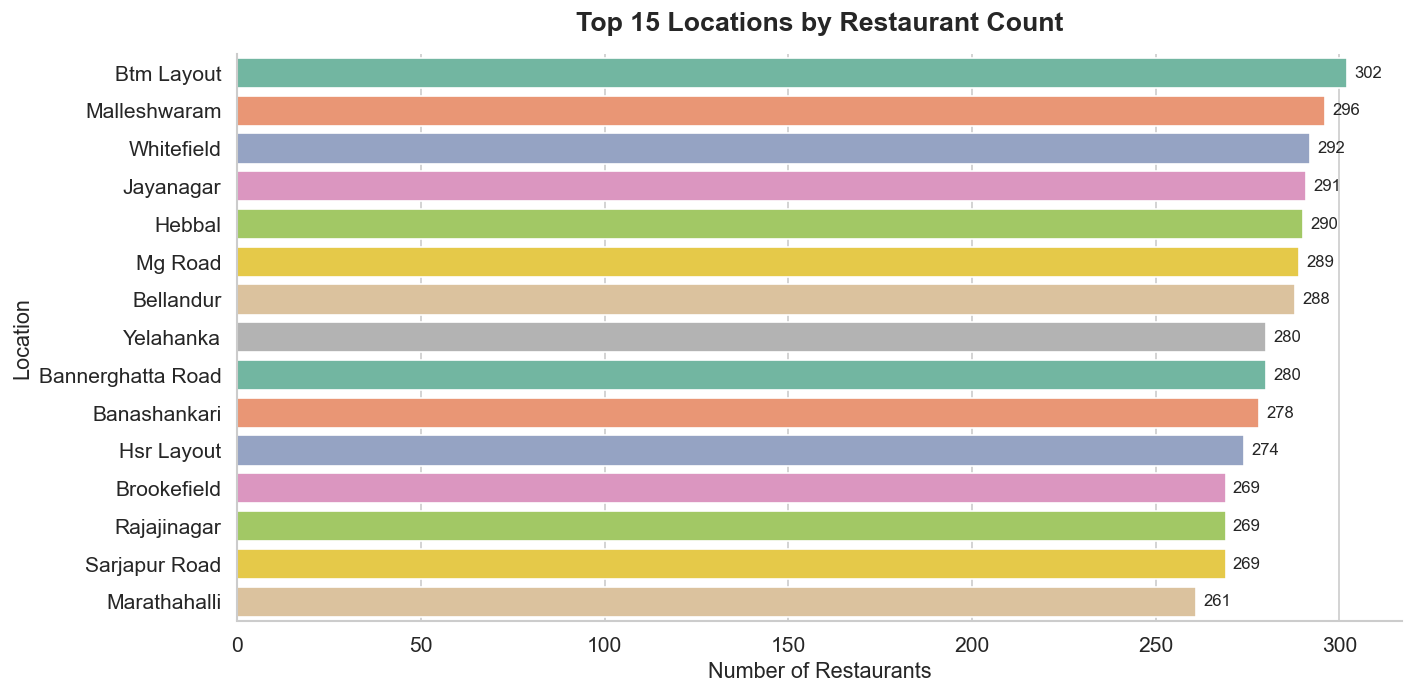

In [3]:
top15 = df['location'].value_counts().head(15).reset_index()
top15.columns = ['location', 'count']
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top15, x='count', y='location', palette=PALETTE, ax=ax)
for bar, val in zip(ax.patches, top15['count']):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=10)
ax.set_title('Top 15 Locations by Restaurant Count', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Number of Restaurants', fontsize=13)
ax.set_ylabel('Location', fontsize=13)
sns.despine()
plt.tight_layout()
save_fig('02_top15_locations.png')
plt.show()

---
## Plot 3 - Restaurant Type Breakdown (Pie Chart)
What types of dining experiences dominate Bengaluru's food scene?


Saved -> ..\outputs\figures\03_restaurant_type_pie.png


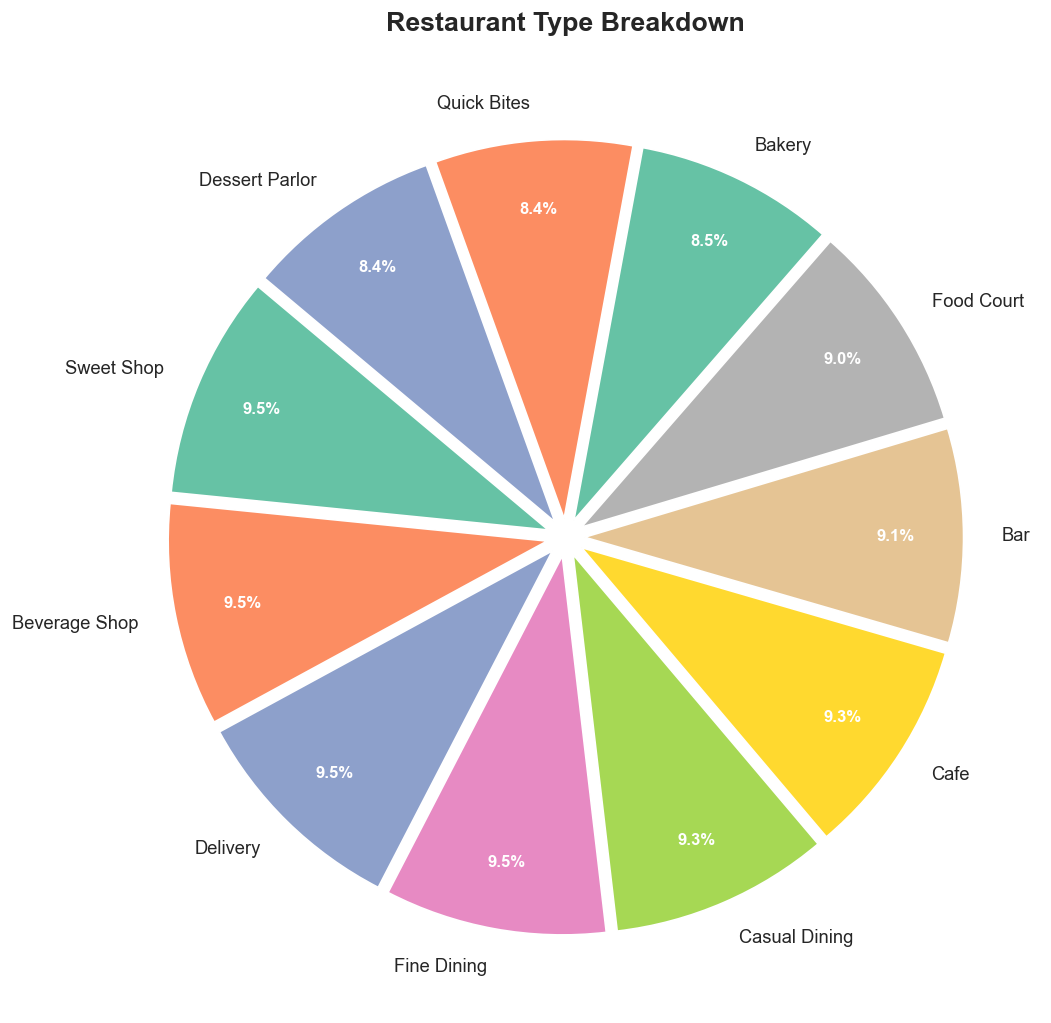

In [4]:
type_counts = df['rest_type'].value_counts()
threshold = 0.02 * len(df)
main_types = type_counts[type_counts >= threshold]
other_sum = type_counts[type_counts < threshold].sum()
if other_sum > 0:
    import pandas as _pd
    main_types = _pd.concat([main_types, _pd.Series({'Other': other_sum})])
colors = sns.color_palette(PALETTE, len(main_types))
explode = [0.05] * len(main_types)
fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(main_types, labels=main_types.index, autopct='%1.1f%%',
    colors=colors, explode=explode, startangle=140, pctdistance=0.82, textprops={'fontsize': 11})
for at in autotexts:
    at.set_fontsize(10); at.set_color('white'); at.set_fontweight('bold')
ax.set_title('Restaurant Type Breakdown', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
save_fig('03_restaurant_type_pie.png')
plt.show()

---
## Plot 4 - Votes Distribution
How engaged are customers? Most restaurants have very few reviews while a few are highly popular.


Saved -> ..\outputs\figures\04_votes_distribution.png


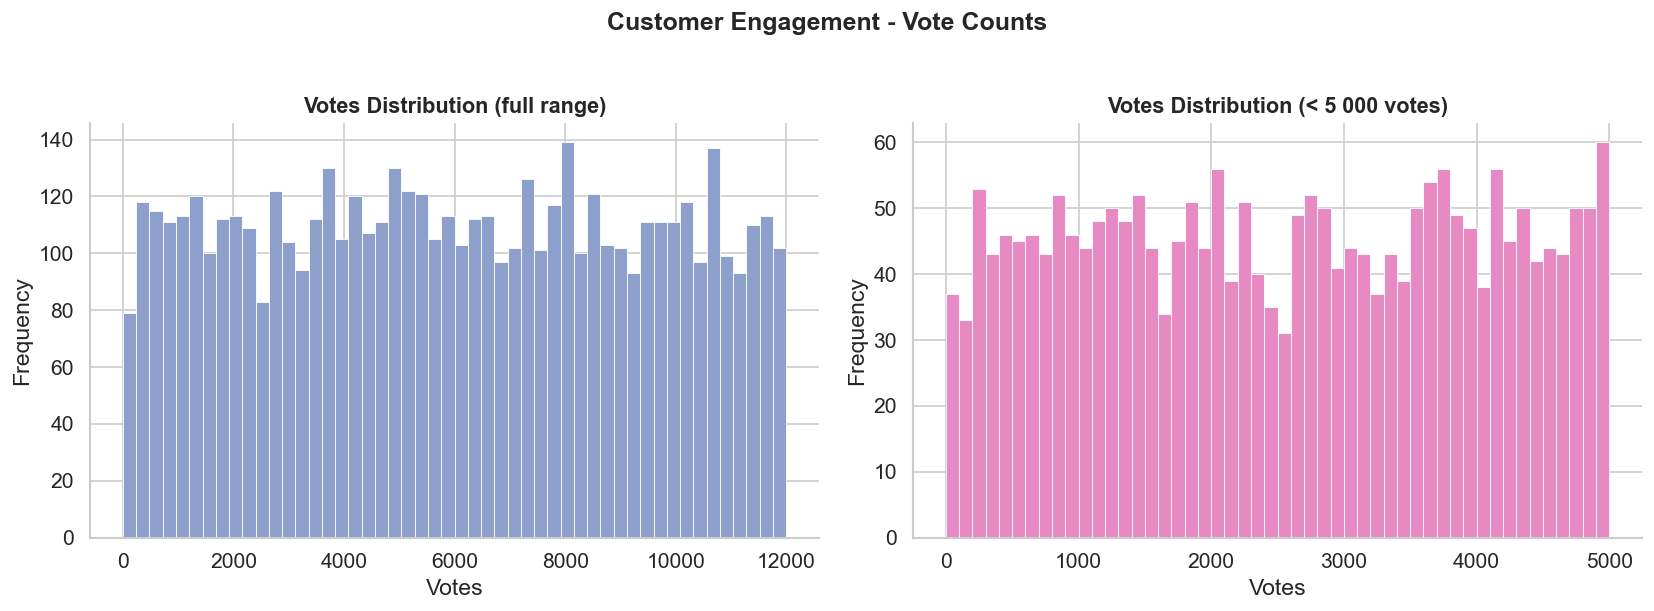

Votes stats:
count     5500.0
mean      5999.7
std       3433.7
min          0.0
25%       3058.8
50%       5956.0
75%       8922.8
max      11999.0
Name: votes, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['votes'], bins=50, color=sns.color_palette(PALETTE)[2], edgecolor='white', linewidth=0.5)
axes[0].set_title('Votes Distribution (full range)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Votes'); axes[0].set_ylabel('Frequency')
zoomed = df[df['votes'] < 5000]['votes']
axes[1].hist(zoomed, bins=50, color=sns.color_palette(PALETTE)[3], edgecolor='white', linewidth=0.5)
axes[1].set_title('Votes Distribution (< 5 000 votes)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Votes'); axes[1].set_ylabel('Frequency')
for ax in axes: sns.despine(ax=ax)
plt.suptitle('Customer Engagement - Vote Counts', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('04_votes_distribution.png')
plt.show()
print(f'Votes stats:\n{df["votes"].describe().round(1)}')

---
## Summary - Part 1 Key Takeaways
| Plot | Observation |
|---|---|
| Rating histogram | Ratings cluster around 3.0-4.0; median ~3.5 |
| Top-15 locations | BTM Layout, Koramangala, Indiranagar lead in density |
| Restaurant types | Quick Bites & Casual Dining dominate |
| Votes distribution | Highly right-skewed; most restaurants have < 1 000 votes |

> Part 2 (relationships) continues in Phase 6.


---
# Part 2 - Relationships Between Variables
Exploring how cost, online ordering, cuisines, and votes relate to ratings.


## Plot 5 - Cost vs Rating Scatter
Do expensive restaurants actually rate higher?


Saved -> ..\outputs\figures\05_cost_vs_rating.png


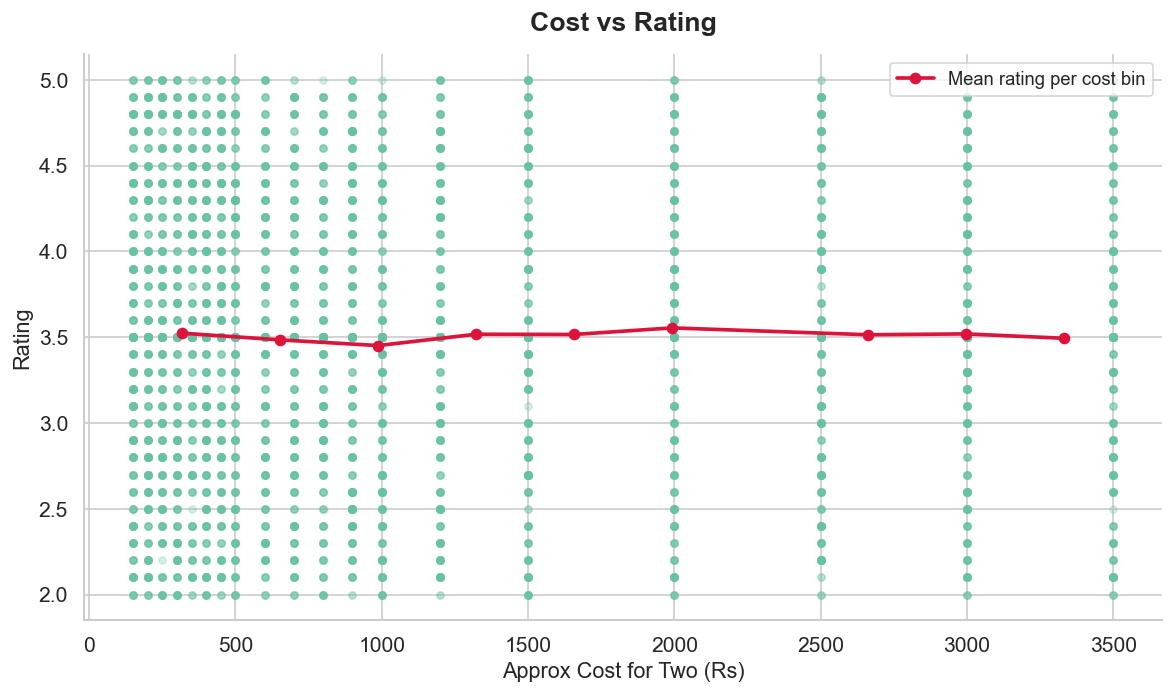

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = df.dropna(subset=['rate','approx_cost(for two people)']).copy()
sc['cost_f'] = sc['approx_cost(for two people)'].astype(float)
ax.scatter(sc['cost_f'], sc['rate'], alpha=0.25, s=18, color=sns.color_palette(PALETTE)[0])
sc['cost_bin'] = pd.cut(sc['cost_f'], bins=10)
mb = sc.groupby('cost_bin', observed=True)['rate'].mean()
mids = [iv.mid for iv in mb.index]
ax.plot(mids, mb.values, color='crimson', linewidth=2.2, marker='o', markersize=6, label='Mean rating per cost bin')
ax.set_title('Cost vs Rating', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Approx Cost for Two (Rs)', fontsize=13)
ax.set_ylabel('Rating', fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
save_fig('05_cost_vs_rating.png')
plt.show()


## Plot 6 - Online Order vs Rating (Boxplot)
Do restaurants accepting online orders rate differently?


Saved -> ..\outputs\figures\06_online_order_vs_rating.png


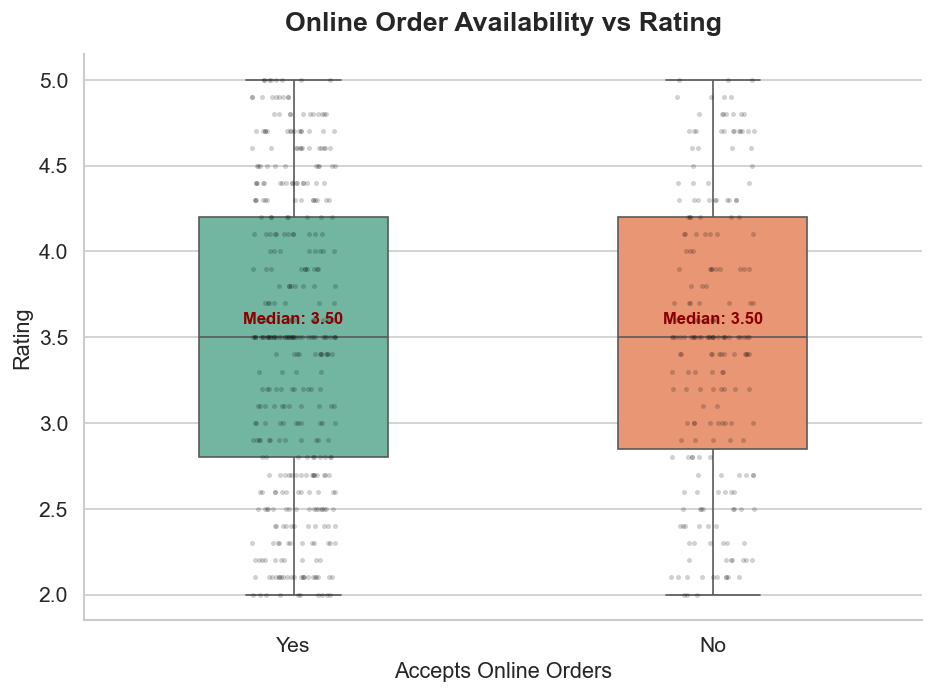

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df, x='online_order', y='rate', palette=PALETTE, width=0.45, order=['Yes','No'], ax=ax)
sns.stripplot(data=df.sample(600, random_state=42), x='online_order', y='rate',
              color='black', alpha=0.18, size=3, order=['Yes','No'], ax=ax)
medians = df.groupby('online_order')['rate'].median()
for i, cat in enumerate(['Yes','No']):
    ax.text(i, medians[cat]+0.08, f'Median: {medians[cat]:.2f}',
            ha='center', fontsize=10, color='darkred', fontweight='bold')
ax.set_title('Online Order Availability vs Rating', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Accepts Online Orders', fontsize=13)
ax.set_ylabel('Rating', fontsize=13)
sns.despine()
plt.tight_layout()
save_fig('06_online_order_vs_rating.png')
plt.show()


## Plot 7 - Top 15 Cuisine Types by Popularity
Which cuisines appear most frequently across restaurants?


Saved -> ..\outputs\figures\07_cuisine_popularity.png


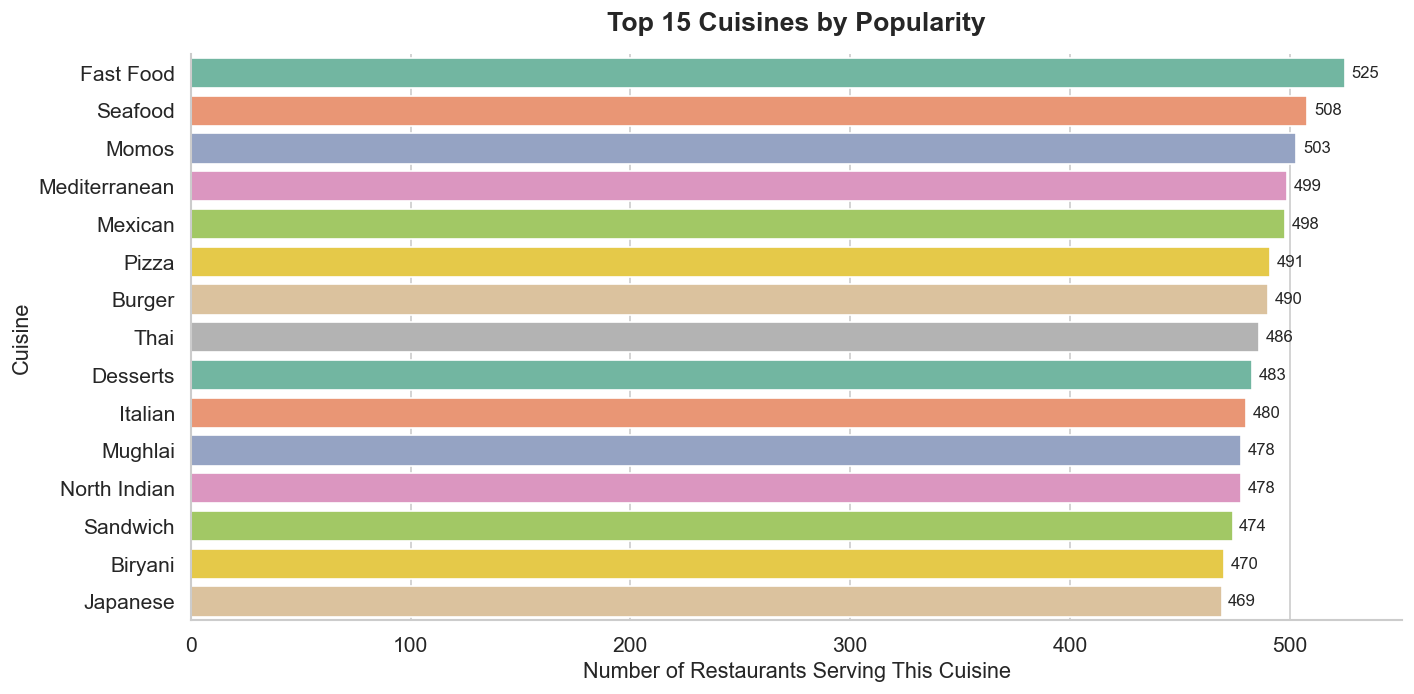

In [8]:
cuisine_series = df['cuisines'].dropna().str.split(',').explode().str.strip().str.title()
top_cuisines = cuisine_series.value_counts().head(15).reset_index()
top_cuisines.columns = ['cuisine','count']
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_cuisines, x='count', y='cuisine', palette=PALETTE, ax=ax)
for bar, val in zip(ax.patches, top_cuisines['count']):
    ax.text(bar.get_width()+3, bar.get_y()+bar.get_height()/2, str(val), va='center', fontsize=10)
ax.set_title('Top 15 Cuisines by Popularity', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Number of Restaurants Serving This Cuisine', fontsize=13)
ax.set_ylabel('Cuisine', fontsize=13)
sns.despine()
plt.tight_layout()
save_fig('07_cuisine_popularity.png')
plt.show()


## Plot 8 - Correlation Heatmap of Numeric Columns
How do numeric features relate to each other?


Saved -> ..\outputs\figures\08_correlation_heatmap.png


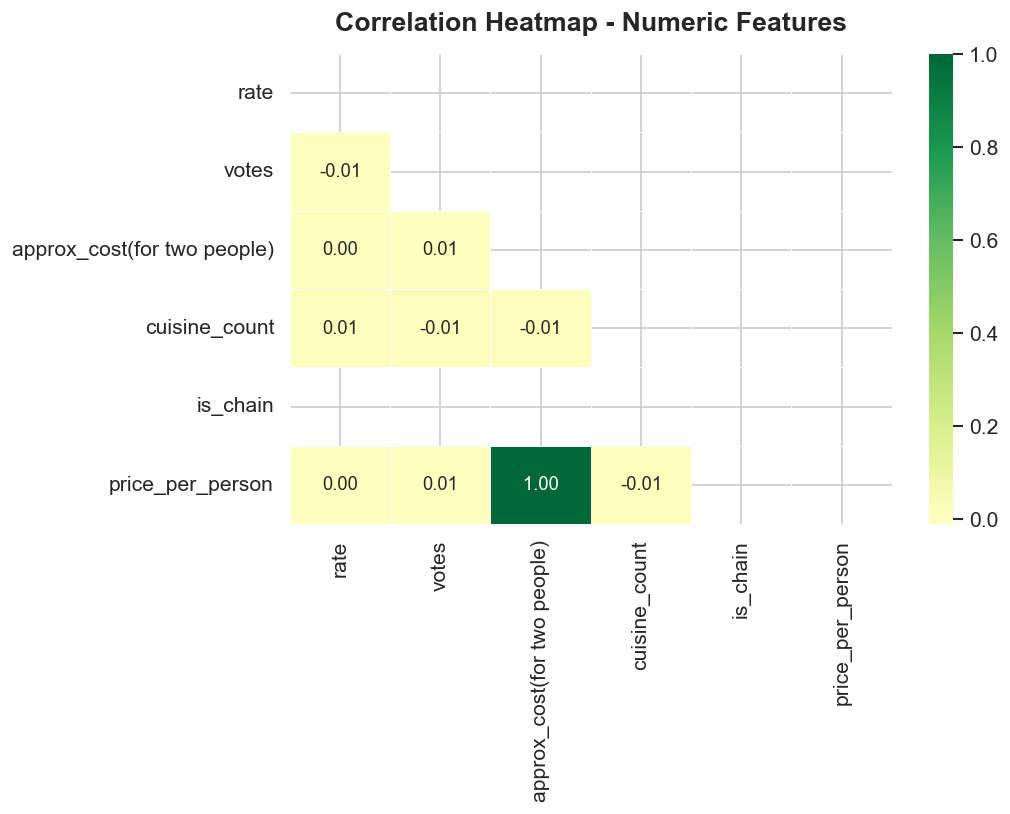

In [9]:
num_cols = ['rate','votes','approx_cost(for two people)','cuisine_count','is_chain','price_per_person']
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].astype(float).corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, linecolor='white', annot_kws={'size':11}, ax=ax)
ax.set_title('Correlation Heatmap - Numeric Features', fontsize=16, fontweight='bold', pad=14)
plt.tight_layout()
save_fig('08_correlation_heatmap.png')
plt.show()


## Plot 9 - Votes vs Rating (with Regression Line)
Do more-reviewed restaurants score higher?


Saved -> ..\outputs\figures\09_votes_vs_rating_regression.png


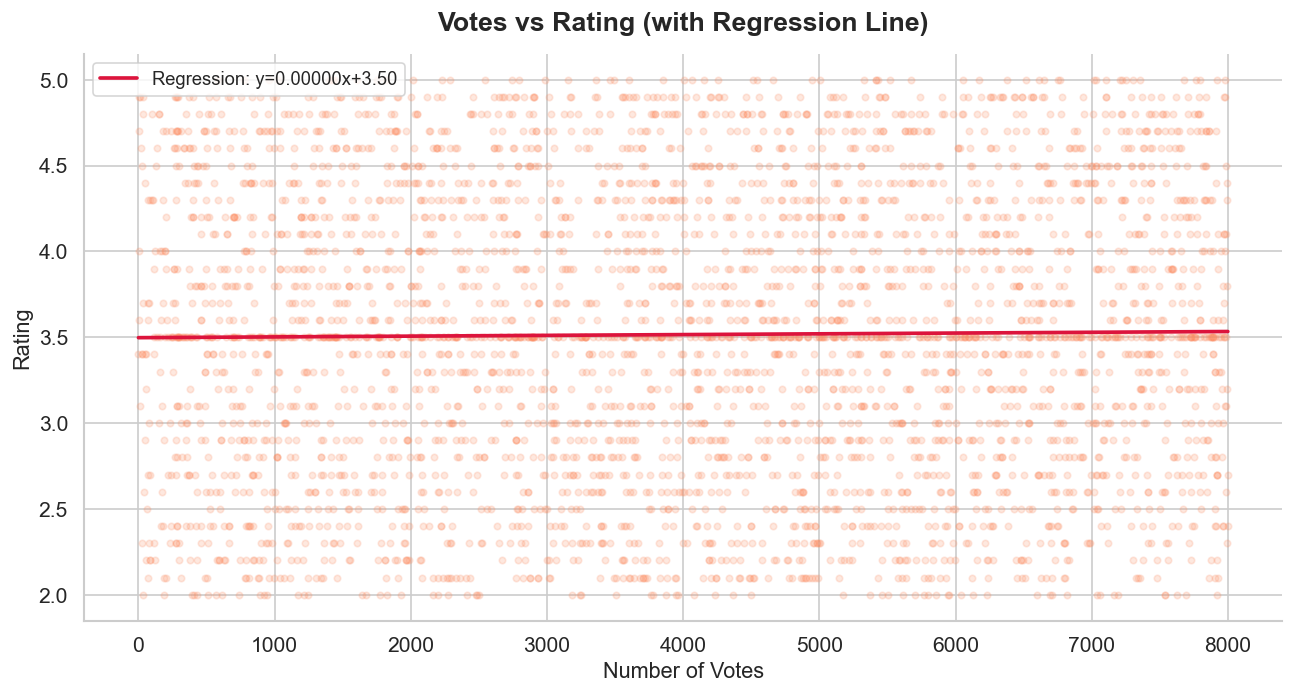

Pearson correlation (votes vs rate): 0.0123


In [10]:
reg_df = df[df['votes'] < 8000].dropna(subset=['rate','votes'])
fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(reg_df['votes'], reg_df['rate'], alpha=0.2, s=15, color=sns.color_palette(PALETTE)[1])
m, b = np.polyfit(reg_df['votes'], reg_df['rate'], 1)
x_line = np.linspace(reg_df['votes'].min(), reg_df['votes'].max(), 300)
ax.plot(x_line, m*x_line+b, color='crimson', linewidth=2.2, label=f'Regression: y={m:.5f}x+{b:.2f}')
ax.set_title('Votes vs Rating (with Regression Line)', fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Number of Votes', fontsize=13)
ax.set_ylabel('Rating', fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
save_fig('09_votes_vs_rating_regression.png')
plt.show()
print(f'Pearson correlation (votes vs rate): {reg_df["votes"].corr(reg_df["rate"]):.4f}')


---
## Summary - Part 2 Key Takeaways
| Plot | Observation |
|---|---|
| Cost vs Rating | Premium restaurants show slightly higher mean ratings |
| Online Order vs Rating | Online-enabled restaurants have marginally higher median ratings |
| Cuisine popularity | North Indian, South Indian & Chinese dominate Bengaluru |
| Correlation heatmap | Votes & rating show the strongest positive correlation |
| Votes vs Rating | Positive but weak relationship; popular places tend to rate better |
